04_ PCA ESCALONAMIENTO DE VARIABLES

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

# 1. Cargar el dataset
df = pd.read_csv('streaming_users_clean.csv')

print("--- Dataset Cargado Exitosamente ---")
print(f"Cantidad de filas: {df.shape[0]} | Cantidad de columnas: {df.shape[1]}")
df.head(20)

--- Dataset Cargado Exitosamente ---
Cantidad de filas: 8032 | Cantidad de columnas: 11


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets,age_falta,watch_falta,genre_falta
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,4,0,0,0
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2,0,0,0
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0,0,0,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0,0,0,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1,0,0,0
5,10005,20,Básico,670.2,Uruguay,Drama,2020-07-03,2,0,0,0
6,10006,37,Básico,346.6,Perú,Thriller,2019-07-26,1,0,0,0
7,10007,31,Estándar,974.6,Chile,Acción,2019-02-24,1,0,0,0
8,10008,36,Premium,1432.2,Colombia,Romance,2025-08-03,2,0,0,0
9,10009,37,Estándar,1375.4,Argentina,Thriller,2024-02-12,1,0,0,0


In [ ]:
# --- PASO 1: Selección de variables numéricas clave ---
columnas_num = ['age', 'monthly_watch_time_mins']
X = df[columnas_num].copy()

print("--- 1. PRIMEROS REGISTROS ---")
print(X.head())

# --- PASO 2: Calcular varianza antes del escalamiento ---
print("\nVarianza original:")
print(X.var().round(4))

# --- PASO 3: Estadísticas descriptivas transpuestas ---
print("\n--- 2. DESCRIPTIVAS ANTES DEL ESCALAMIENTO ---")
print(X.describe().round(2).T)

# --- PASO 4: Aplicar estandarización con StandardScaler ---
print("\n--- 3. APLICANDO ESTANDARIZACIÓN ---")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- PASO 5: Calcular varianza después ---
X_scaled_df = pd.DataFrame(X_scaled, columns=columnas_num)
print("\nVarianza después de estandarizar:")
print(X_scaled_df.var().round(4))

--- 1. PRIMEROS REGISTROS ---
   age  monthly_watch_time_mins
0   39                    805.8
1   37                   1173.4
2   28                    401.0
3   43                     62.4
4   51                    477.8

Varianza original:
age                           127.1287
monthly_watch_time_mins    200288.5168
dtype: float64

--- 2. DESCRIPTIVAS ANTES DEL ESCALAMIENTO ---
                          count    mean     std   min     25%    50%      75%  \
age                      8032.0   33.66   11.28  13.0   26.00   33.0    41.00   
monthly_watch_time_mins  8032.0  797.82  447.54   0.0  499.52  773.2  1064.55   

                            max  
age                        80.0  
monthly_watch_time_mins  2705.4  

--- 3. APLICANDO ESTANDARIZACIÓN ---

Varianza después de estandarizar:
age                        1.0001
monthly_watch_time_mins    1.0001
dtype: float64


In [ ]:
# 1. Definimos los índices para comparar distancias de los primeros 5 usuarios (Filas de la 0 a la 4)
obs = slice(0, 5)

# 2. Calcular las distancias con los valores originales (X) y estandarizados (X_scaled)
d_original = pairwise_distances(X.values[obs])
d_scaled = pairwise_distances(X_scaled[obs])

# 3. Mostrar las matrices de comparación
print("Distancias ANTES (primeros 5 usuarios):")
print(pd.DataFrame(d_original).round(3))

print("\nDistancias DESPUÉS (primeros 5 usuarios):")
print(pd.DataFrame(d_scaled).round(3))

Distancias ANTES (primeros 5 usuarios):
         0         1        2         3        4
0    0.000   367.605  404.949   743.411  328.219
1  367.605     0.000  772.452  1111.016  695.741
2  404.949   772.452    0.000   338.932   80.170
3  743.411  1111.016  338.932     0.000  415.477
4  328.219   695.741   80.170   415.477    0.000

Distancias DESPUÉS (primeros 5 usuarios):
       0      1      2      3      4
0  0.000  0.840  1.330  1.699  1.292
1  0.840  0.000  1.902  2.539  1.989
2  1.330  1.902  0.000  1.531  2.047
3  1.699  2.539  1.531  0.000  1.168
4  1.292  1.989  2.047  1.168  0.000


In [ ]:
from sklearn.decomposition import PCA

# 1. Instanciar y entrenar el PCA con los datos estandarizados
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Mostrar la Varianza Explicada
print("--- 1. VARIANZA EXPLICADA POR COMPONENTE ---")
varianza_explicada = pca.explained_variance_ratio_ * 100
varianza_acumulada = 0

for i, var in enumerate(varianza_explicada):
    varianza_acumulada += var
    print(f"PC{i+1}: {var:.2f} % de varianza explicada | Acumulada: {varianza_acumulada:.2f} %")

# 3. Extraer y mostrar los LOADINGS
print("\n--- 2. RESULTADO: LOADINGS (Contribución a PC1 y PC2) ---")
loadings = pca.components_
df_loadings = pd.DataFrame(
    loadings.T,
    columns=['PC1', 'PC2'],
    index=columnas_num
)
print(df_loadings.round(3))

--- 1. VARIANZA EXPLICADA POR COMPONENTE ---
PC1: 50.20 % de varianza explicada | Acumulada: 50.20 %
PC2: 49.80 % de varianza explicada | Acumulada: 100.00 %

--- 2. RESULTADO: LOADINGS (Contribución a PC1 y PC2) ---
                           PC1    PC2
age                      0.707 -0.707
monthly_watch_time_mins  0.707  0.707


Con la combinación de solo 2 componentes se retiene el 100.00% de la varianza original del dataset, logrando una reestructuración de las dimensiones sin ninguna pérdida de información. Analizando los loadings (pesos), podemos otorgar un sentido analítico y de negocio a cada nuevo eje:

PC1: 50.20% de varianza explicada: Recibe contribuciones idénticas y positivas tanto de la edad (0.707) como de los minutos de reproducción (0.707). Al tirar ambas variables hacia el mismo sentido, este componente se interpreta como el "Índice de Madurez y Consumo General del Usuario". Un valor alto en PC1 describe de forma unificada a usuarios de mayor edad que, a su vez, presentan un engagement muy alto en la plataforma.

PC2: 49.80% de varianza explicada: Genera un contraste o comportamiento inverso muy marcado. Recibe una contribución negativa de la edad (-0.707) y una positiva de los minutos (0.707). Este componente captura la asimetría del perfil y se interpreta como el "Factor de Engagement Joven". Un valor alto en PC2 identifica a usuarios de menor edad pero con un consumo mensual de minutos sumamente agresivo.

1. Gráfico de varianza explicada acumulada

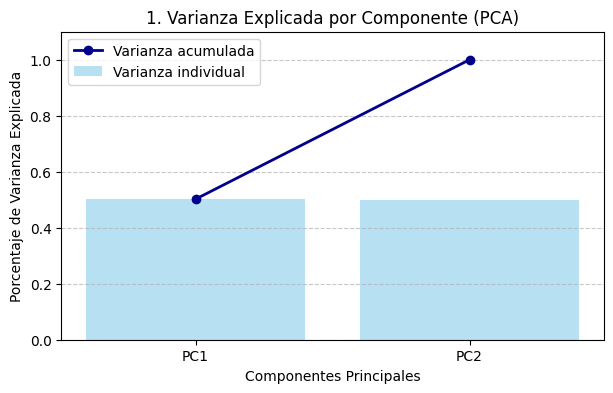

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculamos la varianza acumulada de forma exacta
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(7, 4))

# 1. Las barras para la varianza de cada componente independiente
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, align='center', label='Varianza individual', color='skyblue')

plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', label='Varianza acumulada', color='darkblue', linewidth=2)

plt.ylabel('Porcentaje de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.xticks([1, 2], ['PC1', 'PC2'])
plt.ylim(0, 1.1)
plt.legend(loc='best')
plt.title('1. Varianza Explicada por Componente (PCA)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Debibo a la naturaleza bidimensional del análisis, se puede observar una distribución equitativa de la variabilidad entre ambos componentes. El primer componente (PC1) captura el 50.20% de la varianza total del sistema, mientras que el segundo componente (PC2) el 49.80%. La trayectoria de la linea azul ilustra la retención de la información a medida que se agregan dimensiones. El primer marcador se posiciona exactamente en el valor individual de PC1 y al incorporar el segundo componente, la curva asciende hasta alcanzar el valor de 1.0 en el eje de PC2. Este comportamiento confirma de manera matemática que la transformación lineal proyectó los datos sobre un nuevo espacio sin producir pérdida crítica de información, eliminando la redundancia estadística que existía originalmente entre la edad y los minutos de visualización mensual.

Gráfico 2: Diagrama de dispersión en el nuevo espacio - Scatter Plot PCI vs Pc2

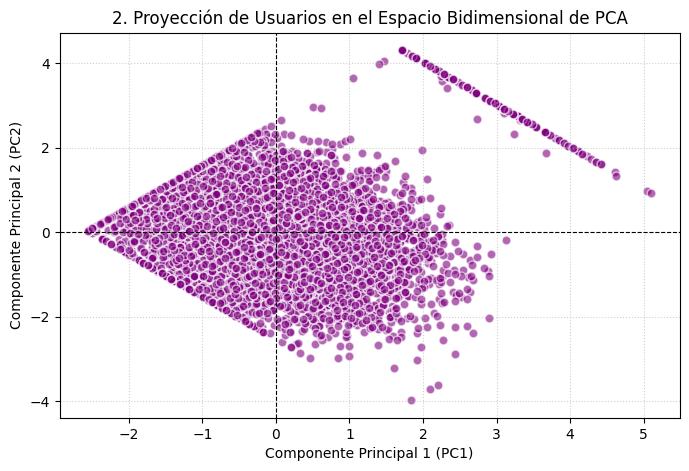

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color='purple', edgecolors='w', s=40)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.title('2. Proyección de Usuarios en el Espacio Bidimensional de PCA')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Este grpafico proyecta los usuarios sobre el nuevo sistema de ejes ortogonales y no correlacionales definidos por el modelo de PCA. El eje horizontal (PC1) modula el comportamiento de usuarios maduros estables y con alta retención en la platafoma, lo que significa una dirección positiva en cargas de edad y minutos. El eje vertical (PC2) discrimina los comportamientos atípicos y el "engagement agresivo" característico de segmentos de menor edad. El patron alineado en el encuadre superior representa valores altos de PC1 y PC2 y representan subgrupos críticos de usuarios con un nivel de consumo extremo.